# Step 1 : Thu thập dữ liệu

- Bài toán: regression dự đoán Purchase Amount (USD) của một lượt mua hàng dựa trên thông tin khách hàng, sản phẩm, lịch sử mua, khuyến mãi và mùa vụ.
- Dataset: Customer Shopping Trends Dataset.
- Nguồn Kaggle: https://www.kaggle.com/datasets/iamsouravbanerjee/customer-shopping-trends-dataset
- Mô tả: Mỗi dòng là một bản ghi mua hàng. Dataset không có ngày/thời gian nên đây là tabular regression
- Mô tả trường: 
   - Customer ID (mã khách hàng), 
   - Age (tuổi), 
   - Gender, 
   - Item Purchased, 
   - Category, 
   - Purchase Amount (USD) (target), 
   - Location, 
   - Size, 
   - Color, 
   - Season, 
   - Review Rating, 
   - Subscription Status, 
   - Payment/Shipping, 
   - Discount Applied, 
   - Promo Code Used, 
   - Previous Purchases và Frequency of Purchases.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
from src.models import MeanBaseline, LinearRegressionScratch, DecisionTreeRegressorScratch
from src.metrics import regression_metrics
from src.features import engineer_features, feature_columns
from src.preprocessing import random_split, fit_preprocessor, transform_splits
sns.set_theme(style='whitegrid')

In [2]:
data=pd.read_csv(Path('data/raw/shopping_trends.csv'))
data.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


# Step 2 : Thống kê và trực quan hóa dữ liệu

In [3]:
print('CÁC GIÁ TRỊ CƠ BẢN CỦA DỮ LIỆU')
display(data.head())
print('KÍCH THƯỚC DỮ LIỆU:',data.shape)
print('CÁC GIÁ TRỊ THỐNG KÊ CƠ BẢN')
display(data.describe(include='all').T)
print('CÁC THÔNG TIN CƠ BẢN')
data.info()
print('CÁC GIÁ TRỊ NULL')
print(data.isnull().sum())
print('SỐ DÒNG TRÙNG LẶP:',data.duplicated().sum())

CÁC GIÁ TRỊ CƠ BẢN CỦA DỮ LIỆU


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


KÍCH THƯỚC DỮ LIỆU: (3900, 19)
CÁC GIÁ TRỊ THỐNG KÊ CƠ BẢN


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer ID,3900.0,NaN,NaN,NaN,1950.5,1125.977353,1.0,975.75,1950.5,2925.25,3900.0
Age,3900.0,NaN,NaN,NaN,44.068462,15.207589,18.0,31.0,44.0,57.0,70.0
Gender,3900,2,Male,2652,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item Purchased,3900,25,Blouse,171,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,3900,4,Clothing,1737,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Purchase Amount (USD),3900.0,NaN,NaN,NaN,59.764359,23.685392,20.0,39.0,60.0,81.0,100.0
Location,3900,50,Montana,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,3900,4,M,1755,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Color,3900,25,Olive,177,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,3900,4,Spring,999,NaN,NaN,NaN,NaN,NaN,NaN,NaN


CÁC THÔNG TIN CƠ BẢN
<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   str    
 3   Item Purchased            3900 non-null   str    
 4   Category                  3900 non-null   str    
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   str    
 7   Size                      3900 non-null   str    
 8   Color                     3900 non-null   str    
 9   Season                    3900 non-null   str    
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   str    
 12  Payment Method            3900 non-null   str    
 13  Shipping Type             3900 non-null   str    
 14

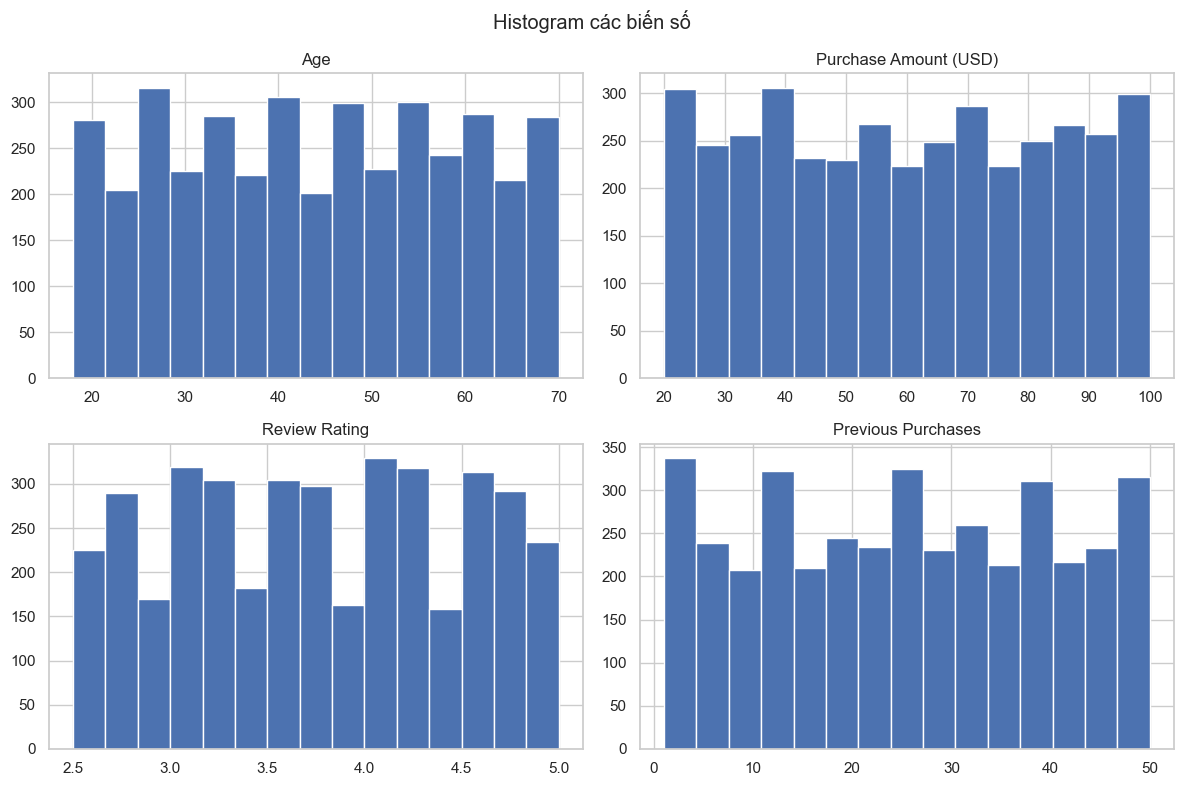

In [4]:
numeric_cols=['Age','Purchase Amount (USD)','Review Rating','Previous Purchases']
data[numeric_cols].hist(bins=15,figsize=(12,8))
plt.suptitle('Histogram các biến số')
plt.tight_layout()
plt.show()

Histogram cho thấy phân phối các biến số và target ở thang đo gốc.

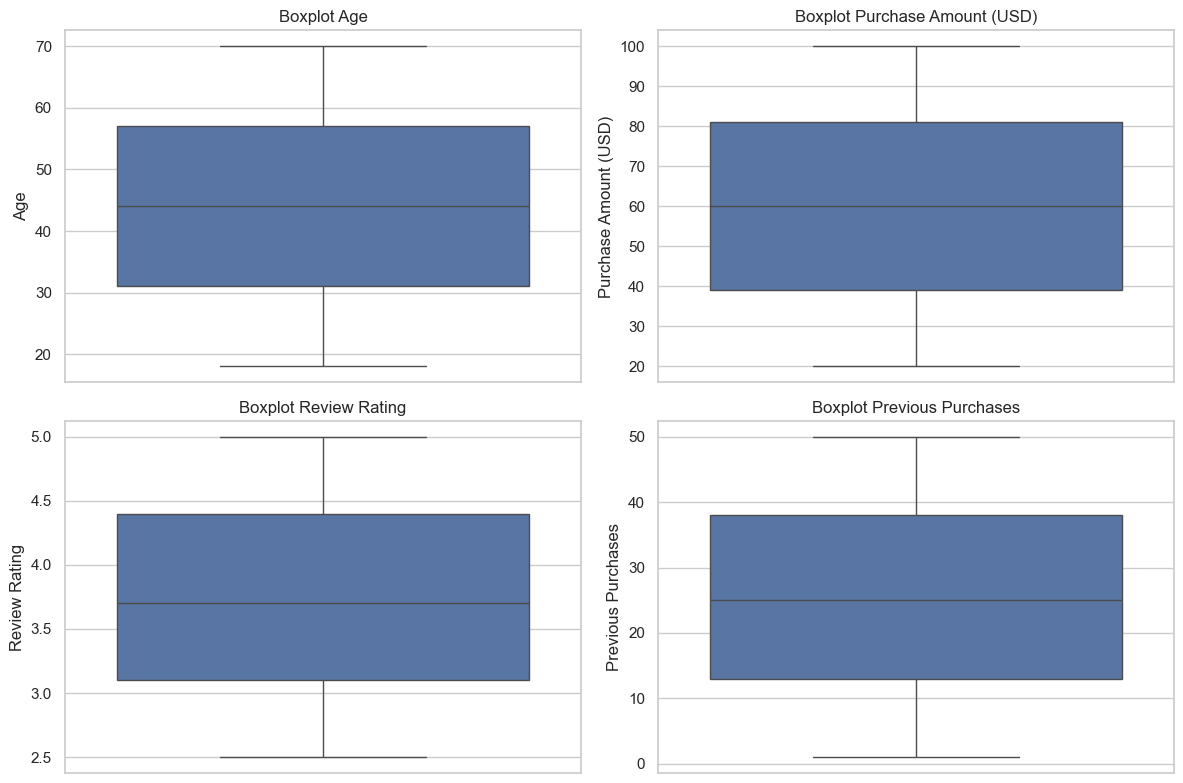

In [5]:
fig,axes=plt.subplots(2,2,figsize=(12,8))
for ax,col in zip(axes.ravel(),numeric_cols):
    sns.boxplot(y=data[col],ax=ax)
    ax.set_title('Boxplot '+col)
plt.tight_layout()
plt.show()

Boxplot dùng để nhận diện outlier; giao dịch thực tế được giữ nguyên.

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
Age,1.000000,-0.010424,-0.021949,0.040445
Purchase Amount (USD),-0.010424,1.000000,0.030776,0.008063
Review Rating,-0.021949,0.030776,1.000000,0.004229
Previous Purchases,0.040445,0.008063,0.004229,1.000000


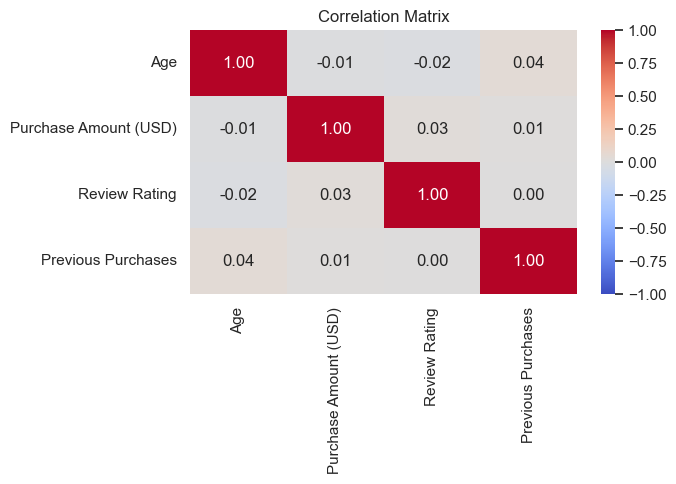

In [6]:
corr=data[numeric_cols].corr()
display(corr)
plt.figure(figsize=(7,5))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f',vmin=-1,vmax=1)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

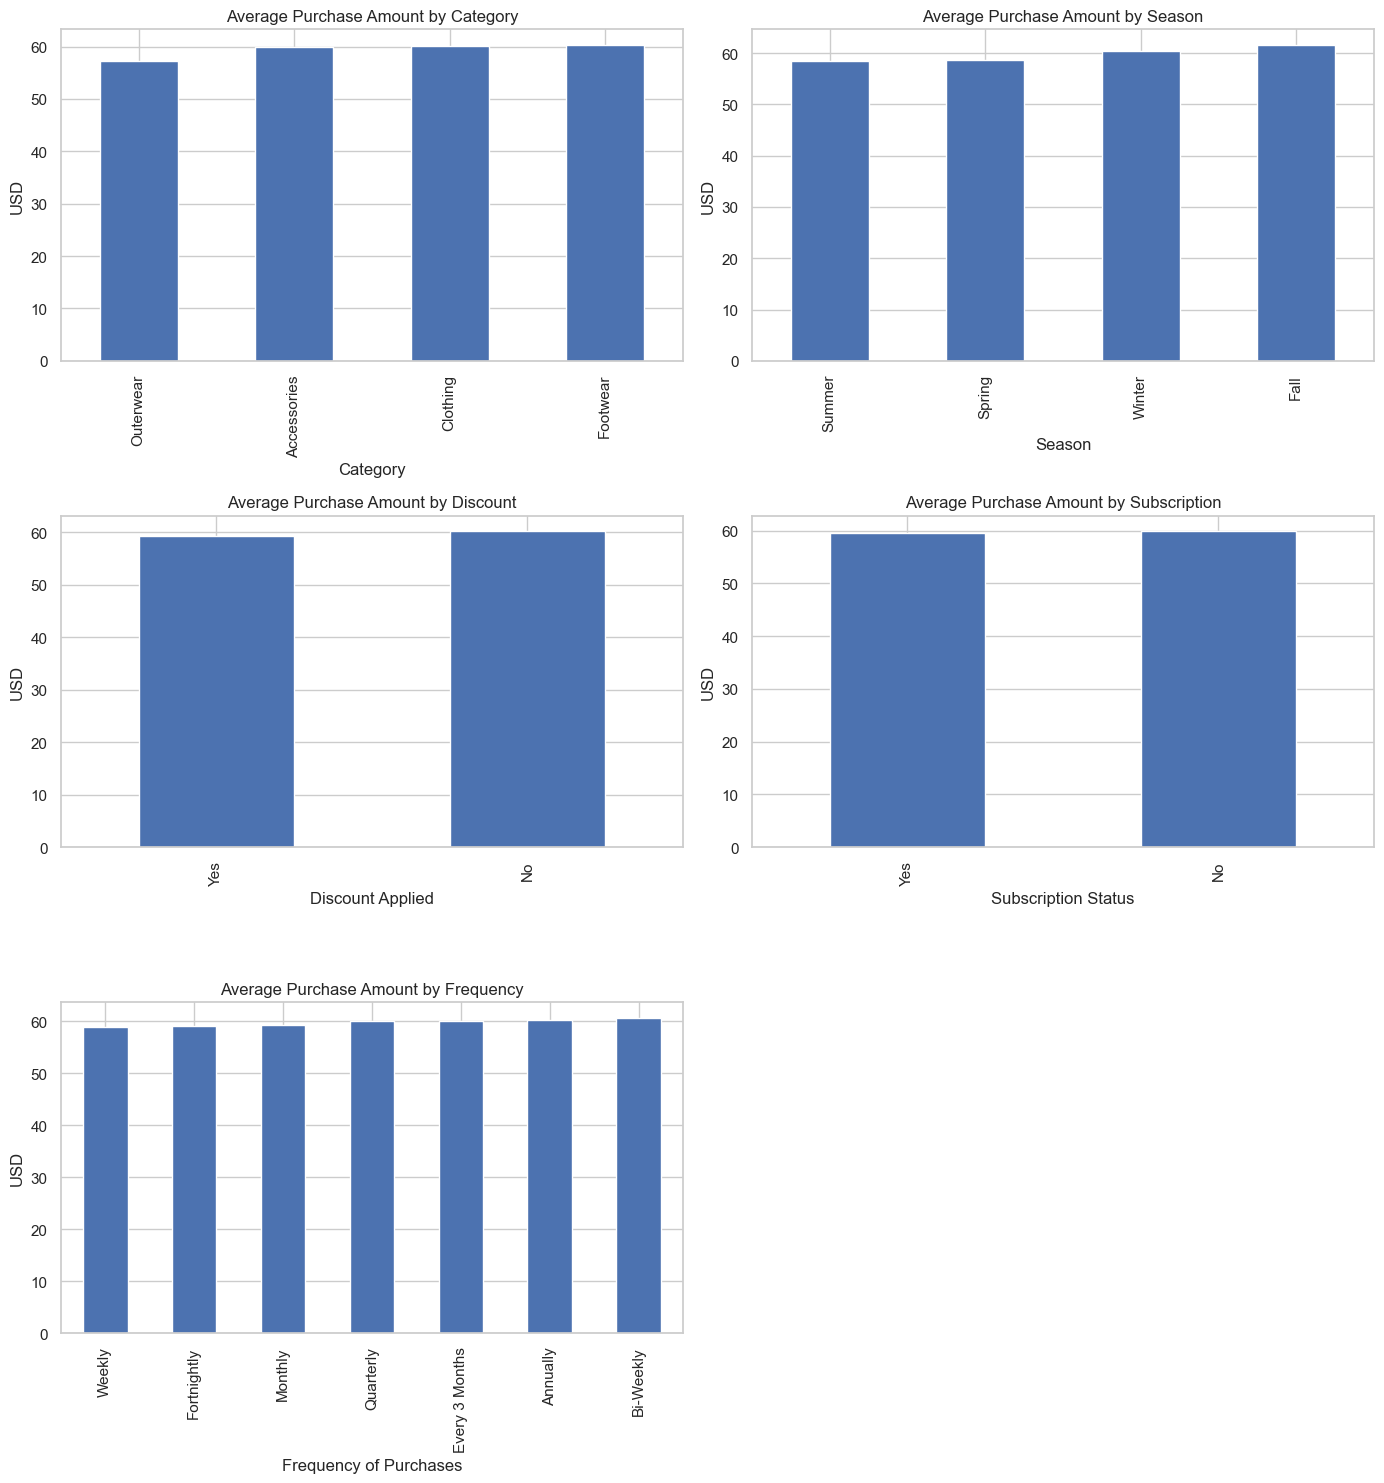

In [7]:
specs=[('Category','Category'),('Season','Season'),('Discount Applied','Discount'),('Subscription Status','Subscription'),('Frequency of Purchases','Frequency')]
fig,axes=plt.subplots(3,2,figsize=(14,15))
for ax,(col,title) in zip(axes.ravel(),specs):
    data.groupby(col)['Purchase Amount (USD)'].mean().sort_values().plot.bar(ax=ax)
    ax.set_title('Average Purchase Amount by '+title)
    ax.set_ylabel('USD')
axes.ravel()[-1].axis('off')
plt.tight_layout()
plt.show()

# Kết luận

- Dataset có 3.900 dòng và 19 cột; missing và duplicate được kiểm tra trực tiếp.
- Không có timestamp nên không tạo lag, rolling hoặc next-month target.
- Customer ID là định danh và Review Rating có thể phát sinh sau mua, nên loại khỏi feature set production-style.
- Các biểu đồ nhóm mô tả khác biệt trung bình, không khẳng định quan hệ nhân quả.

# Step 3 : Tiền xử lí dữ liệu

## Fill các giá trị Missing

In [8]:
missing=data.isnull().sum()
print(missing[missing>0])
if missing.sum()==0:
    print('Dataset không có missing value, vì vậy không cần fill dữ liệu.')

Series([], dtype: int64)
Dataset không có missing value, vì vậy không cần fill dữ liệu.


## Feature engineering

In [9]:
frequency_map={'Weekly':52,'Fortnightly':26,'Bi-Weekly':26,'Monthly':12,'Every 3 Months':4,'Quarterly':4,'Annually':1}
data['AnnualPurchaseFrequency']=data['Frequency of Purchases'].map(frequency_map).fillna(0)
data['DiscountAndPromo']=((data['Discount Applied']=='Yes')&(data['Promo Code Used']=='Yes')).astype(int)
data[['AnnualPurchaseFrequency','DiscountAndPromo']].head()

,AnnualPurchaseFrequency,DiscountAndPromo
0,26,1
1,26,1
2,52,1
3,52,1
4,1,1


AnnualPurchaseFrequency đổi tần suất chữ thành số lần mua ước tính mỗi năm. DiscountAndPromo đánh dấu giao dịch vừa giảm giá vừa dùng mã khuyến mãi.

## Tiền xử lí dữ liệu

In [10]:
TARGET='Purchase Amount (USD)'
base=data.copy()
base['product_sales_amount_usd']=base[TARGET].astype(float)
splits_raw=random_split(base,seed=42)
print('Train:',splits_raw['train'].shape)
print('Validation:',splits_raw['validation'].shape)
print('Test:',splits_raw['test'].shape)
print('Tổng:',sum(len(v) for v in splits_raw.values()))

Train: (2730, 22)
Validation: (585, 22)
Test: (585, 22)
Tổng: 3900


In [11]:
engineered={}
for name,part in splits_raw.items():
    engineered[name],_=engineer_features(part,train_frame=splits_raw['train'])
num_features,cat_features=feature_columns()
preprocessor=fit_preprocessor(engineered['train'],num_features,cat_features)
matrices,targets=transform_splits(preprocessor,engineered)
X_train_p,X_val_p,X_test_p=matrices['train'],matrices['validation'],matrices['test']
y_train,y_val,y_test=targets['train'],targets['validation'],targets['test']
print('Numerical:',num_features)
print('Categorical:',cat_features)
print('Transformed shapes:',X_train_p.shape,X_val_p.shape,X_test_p.shape)

Numerical: ['Age', 'Previous Purchases', 'annual_purchase_frequency', 'log_previous_purchases', 'customer_activity_score', 'is_subscriber', 'has_discount', 'used_promo_code', 'discount_promo_interaction', 'item_purchase_frequency_train', 'category_purchase_frequency_train', 'item_mean_review_rating_train', 'category_mean_review_rating_train']
Categorical: ['Gender', 'Item Purchased', 'Category', 'Location', 'Size', 'Color', 'Season', 'Subscription Status', 'Payment Method', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Preferred Payment Method', 'Frequency of Purchases']
Transformed shapes: (2730, 158) (585, 158) (585, 158)


Preprocessing fit trên train; validation/test chỉ dùng state đã lưu. Target, Customer ID và Review Rating không nằm trong X.

# Step 4 : Train model

In [12]:
models={'MeanBaseline':MeanBaseline(),'LinearRegressionScratch':LinearRegressionScratch(learning_rate=0.005,epochs=3000,tol=1e-8),'DecisionTreeScratch':DecisionTreeRegressorScratch(max_depth=4,min_samples_split=10)}
validation_results=[]
trained_models={}
for name,model in models.items():
    model.fit(X_train_p.to_numpy(),y_train.to_numpy())
    pred=model.predict(X_val_p.to_numpy())
    validation_results.append({'Model':name,**regression_metrics(y_val.to_numpy(),pred)})
    trained_models[name]=model
validation_df=pd.DataFrame(validation_results).sort_values('rmse').reset_index(drop=True)
display(validation_df)
best_model_name=validation_df.iloc[0]['Model']
best_model=trained_models[best_model_name]
print('Best model by Validation RMSE:',best_model_name)

,Model,mae,mse,rmse,r2
0,DecisionTreeScratch,19.925626,534.913665,23.128201,-0.002750
1,LinearRegressionScratch,19.979048,539.040314,23.217242,-0.010485
2,MeanBaseline,20.081934,539.415061,23.225311,-0.011188


Best model by Validation RMSE: DecisionTreeScratch


Ba model scratch được fit trực tiếp; chọn model theo Validation RMSE, chưa dùng test.

# Step 5 : Đánh giá

In [13]:
y_pred=np.maximum(best_model.predict(X_test_p.to_numpy()),0.0)
test_metrics=regression_metrics(y_test.to_numpy(),y_pred)
print('--- Báo cáo đánh giá: Best Model ---')
print(f"MAE: {test_metrics['mae']:.4f} USD")
print(f"MSE: {test_metrics['mse']:.4f}")
print(f"RMSE: {test_metrics['rmse']:.4f} USD")
print(f"R2: {test_metrics['r2']:.4f}")

--- Báo cáo đánh giá: Best Model ---
MAE: 20.6576 USD
MSE: 562.6264
RMSE: 23.7197 USD
R2: -0.0134


MAE là độ lệch tuyệt đối trung bình; RMSE phạt mạnh sai số lớn; R² so sánh với baseline. Dự đoán âm được cắt về 0.

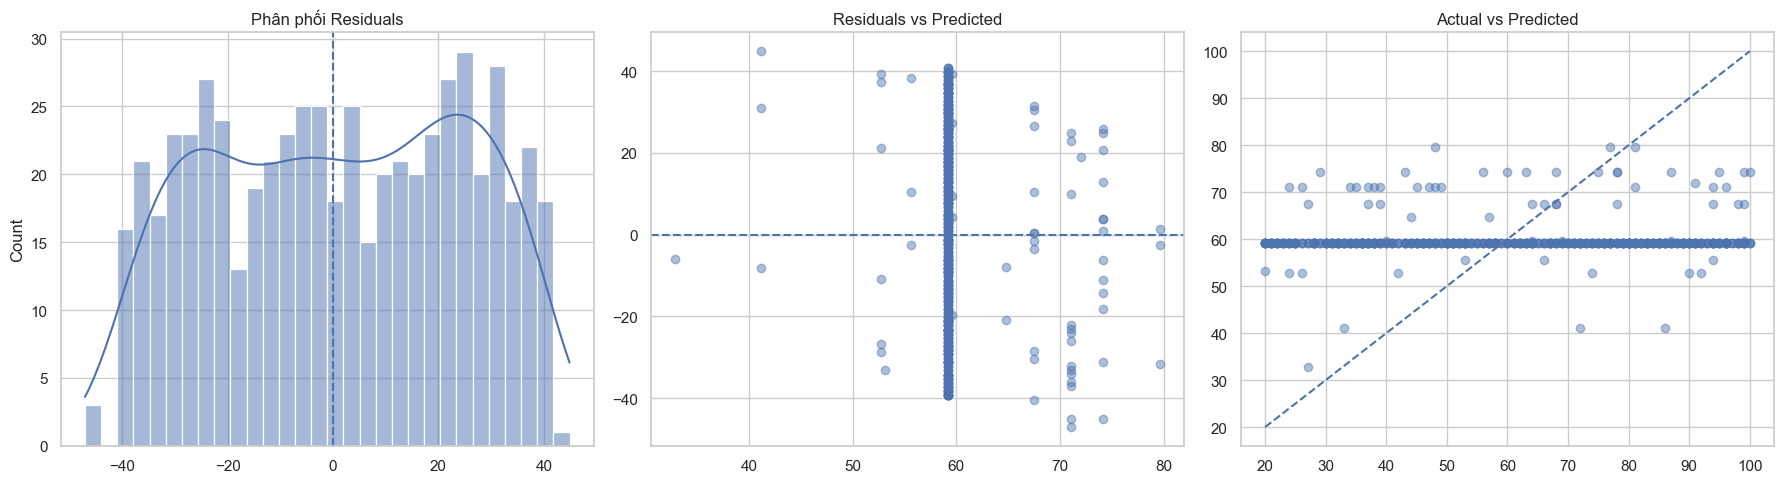

In [14]:
residuals=y_test.to_numpy()-y_pred
fig,axes=plt.subplots(1,3,figsize=(18,5))
sns.histplot(residuals,kde=True,bins=30,ax=axes[0])
axes[0].axvline(0,ls='--'); axes[0].set_title('Phân phối Residuals')
axes[1].scatter(y_pred,residuals,alpha=.45); axes[1].axhline(0,ls='--'); axes[1].set_title('Residuals vs Predicted')
low=min(float(y_test.min()),float(y_pred.min())); high=max(float(y_test.max()),float(y_pred.max()))
axes[2].scatter(y_test,y_pred,alpha=.45); axes[2].plot([low,high],[low,high],ls='--'); axes[2].set_title('Actual vs Predicted')
plt.tight_layout()
plt.show()

Đánh giá dựa trên residual quanh 0, độ phân tán theo mức dự đoán, outlier lớn và mức cải thiện so với MeanBaseline.